In [44]:
import pyvo
from astropy.table import Table
import re
import matplotlib.pyplot as plt
import numpy as np

In [2]:
nasa = pyvo.dal.TAPService("https://exoplanetarchive.ipac.caltech.edu/TAP")


In [3]:
# columns_query = nasa.search("""SELECT top 1 FROM pscomppars""")

In [4]:
# ts = nasa.tables

In [5]:
# print(list(i for i in ts.keys()))


In [6]:
columns_query = nasa.search("SELECT column_name FROM TAP_SCHEMA.columns WHERE table_name = 'pscomppars'")

In [7]:
psc_columns = columns_query["column_name"].data

In [8]:
pattern = re.compile(".*ref.*")

ref_columns = [c for c in psc_columns if pattern.match(c)]
ref_columns

['pl_orbeccen_reflink',
 'pl_eqt_reflink',
 'pl_occdep_reflink',
 'pl_insol_reflink',
 'pl_dens_reflink',
 'pl_trandep_reflink',
 'pl_angsep_reflink',
 'pl_tranmid_reflink',
 'pl_trandur_reflink',
 'pl_rvamp_reflink',
 'pl_radj_reflink',
 'pl_rade_reflink',
 'pl_ratror_reflink',
 'pl_ratdor_reflink',
 'pl_imppar_reflink',
 'pl_bmassj_reflink',
 'pl_bmasse_reflink',
 'st_teff_reflink',
 'st_met_reflink',
 'st_radv_reflink',
 'st_vsin_reflink',
 'st_lum_reflink',
 'st_logg_reflink',
 'st_age_reflink',
 'st_mass_reflink',
 'st_dens_reflink',
 'st_rad_reflink',
 'sy_pm_reflink',
 'sy_plx_reflink',
 'sy_dist_reflink',
 'sy_bmag_reflink',
 'sy_vmag_reflink',
 'sy_jmag_reflink',
 'sy_hmag_reflink',
 'sy_kmag_reflink',
 'sy_umag_reflink',
 'sy_rmag_reflink',
 'sy_imag_reflink',
 'sy_zmag_reflink',
 'sy_w1mag_reflink',
 'sy_w2mag_reflink',
 'sy_w3mag_reflink',
 'sy_w4mag_reflink',
 'sy_gmag_reflink',
 'sy_gaiamag_reflink',
 'sy_tmag_reflink',
 'pl_tranmid_systemref',
 'pl_orbtper_systemref',
 '

In [9]:
len(ref_columns)

61

Trying to find out which columns contain calculated values

In [10]:
from concurrent.futures import ThreadPoolExecutor

def query_caltech(col):
    query = f"SELECT pl_name, {col} FROM pscomppars WHERE {col} LIKE '%Calculated Value%'"
    return nasa.search(query)

# Use ThreadPoolExecutor to run the synchronous searches concurrently
# Adjust max_workers based on the size of ref_columns to avoid hammering the server
with ThreadPoolExecutor() as executor:
    # executor.map preserves the order of your ref_columns
    calc_queries = list(executor.map(query_caltech, ref_columns))

# calc_queries = [
#     nasa.search(f"SELECT pl_name, {col} FROM pscomppars WHERE {col} = 'Calculated Value'")
#     for col in ref_columns
# ]

In [ ]:
total_count = int(nasa.search("SELECT COUNT(*) FROM pscomppars")["count(*)"][0])

6160

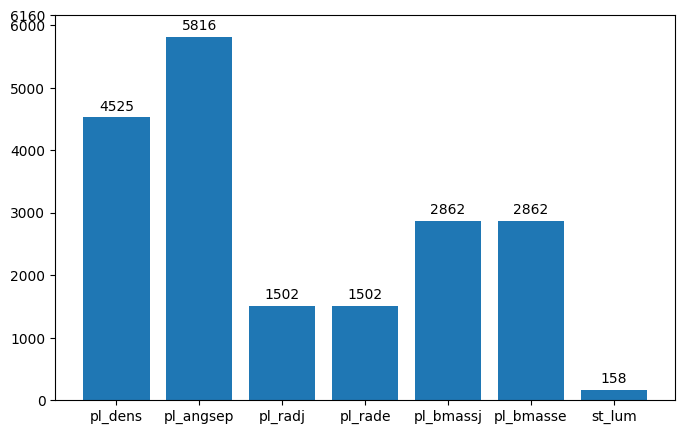

In [50]:
names = []
calcs = []

for q, name in zip(calc_queries, ref_columns):
    if len(q) > 0: 
        names.append(name.replace("_reflink", ''))
        calcs.append(len(q))

fig, ax = plt.subplots(figsize=(8,5))
_ = ax.bar_label(ax.bar(names, calcs), padding=3)
ax.set_ylim(0,total_count)
ax.set_yticks([1000*i for i in range(round(total_count/1000)+1)] + [total_count])
plt.savefig("calculated_columns.svg", bbox_inches="tight")

In [ ]:
nasa.search("SELECT pl_name FROM pscomppars WHERE ")

In [12]:
example_calc_rad = nasa.search("SELECT * FROM pscomppars WHERE pl_name = '11 Com b'")

In [13]:
example_calc_rad["pl_radj_reflink"].data[0]

'<a refstr=CALCULATED_VALUE href=/docs/pscp_calc.html target=_blank>Calculated Value</a>'